In [1]:
# useful to autoreload the module without restarting the kernel
%load_ext autoreload
%autoreload 2

In [2]:
from mppi import InputFiles as I, Calculators as C, Datasets as D, Parsers as P, Utilities as U
from mppi import Optics as O
from mppi.Datasets import PostProcessing as PP
from mppi.Utilities import Constants as Const
from mppi.Utilities import Utils
import matplotlib.pyplot as plt
import numpy as np
import os

# Analysis of the Transient absorption vs Non-linear $\chi$

We study the compared description of the transient absorption based on the pump and probe induced polarization with the one
based on the non-linear chi computed on the basis of the polarization produced by a single pulse.

We use the SAVE folder and collisions matrix elements computed by D.Sangalli here

_/work/sangalli/simulations/LiF/yambo/e80_kx6_pbe_sr/kx8_nb100/NoTr_E100_.

The two descriptions are linked by the following equation that has to be implemented here to perform a comparison of the results

\begin{eqnarray}
\chi^{neq,(1)}[E_P](\omega) &=& \chi^{(1)}(\omega;\omega) + \nonumber \\
&+& \left[ \chi^{(2)}(\omega;\omega_P,\omega-\omega_P)\frac{E_{p}(\omega-\omega_P)}{E_p(\omega)} + 
\chi^{(2)}(\omega;-\omega_P,\omega+\omega_P)\frac{E_{p}(\omega+\omega_P)}{E_p(\omega)}
\right]E_{P}(\omega_P)  + \nonumber \\ &+&\left[   
\chi^{(3)}(\omega;\omega_P,\omega_P,\omega-2\omega_P)\frac{E_{p}(\omega-2\omega_P)}{E_p(\omega)} + 
\chi^{(3)}(\omega;\omega_P,-\omega_P,\omega) + \right. \nonumber \\ &&\left.
\chi^{(3)}(\omega;-\omega_P,-\omega_P,\omega+2\omega_P)\frac{E_{p}(\omega+2\omega_P)}{E_p(\omega)}
\right]E^2_{P}(\omega_P)
\end{eqnarray}

## RT simulation with yambo_nl in the IP approximation

As a first step we peform the RT simulation in the IP approximation.

WE choose the parameters from the folder

/work/sangalli/simulations/LiF/yambo/e80_kx6_pbe_sr/kx8_nb100/NoTr_E100/sh6.0+str0.05_probes/tdberry

and in particular from td-ip-ber_3.0as_inv_3-12b_delta1.0fs_deph0.1fs_p_NL, reducing the bands to 3-6

SOFTSIN:  E(t)= (c*t^2 + b*t^3 + a*t^4 )* sin(t)  and 0 for t<=0

In [4]:
# RunRules for ismhpc
# The product of ntasks_per_node*cpus_per_task is equal to 32. 
# Many mpi are needed for better performances
nodes = 1
ntasks_per_node = 32 #16
cpus_per_task = 1 #2
omp_num_threads = 1 #2
module = '/home/dalessandro/module_script/yambo_module'

ntasks = nodes*ntasks_per_node

rr = C.RunRules(scheduler='slurm',partition='all12h', #'all12h',
                memory='125000',
                nodes=nodes,ntasks_per_node=ntasks_per_node,
                cpus_per_task=cpus_per_task,
                omp_num_threads=omp_num_threads,pre_processing=module)
code = C.YamboCalculator(rr,executable='yambo_nl',activate_BeeOND=True)
#code.global_options()

Initialize a Yambo calculator with scheduler slurm


In [5]:
run_dir = 'kx8_nb100_NoTr_E100/'

### Linear response within the Berry phase approach (delta pulse)

As a first step we compute the linear response of the system using a single delta shaped pulse.
In this way we extract the linear chi to be compared with the same quantity computed from the general procedure below

In [76]:
NLBands = [3,6]
GfnQP_E = [6.,1.05,1.05]

Field1_Int = 1.e3 
Field1_Dir = [1.,0.,0.]
Field1_kind = 'DELTA'
Field1_Tstart = 0.1 # fs
NLDamping = 0.0 # eV
NLtime, NLstep = 100, 0.05  # fs
IOtime = [1.,5.,0.005] #fs

inp = I.YamboInput(args='yambo_nl -u p',folder=run_dir)
inp.set_array_variables(NLBands=NLBands,GfnQP_E=GfnQP_E)
inp.set_array_variables(units='eV',NLDamping=NLDamping)
inp.set_array_variables(units='kWLm2',Field1_Int=Field1_Int)
inp.set_array_variables(Field1_Dir=Field1_Dir)
inp.set_array_variables(units='fs',Field1_Tstart=Field1_Tstart,NLtime=NLtime,NLstep=NLstep)
inp.set_scalar_variables(Field1_kind=Field1_kind)
inp.set_array_variables(units='fs',IOtime=IOtime)
#inp.set_scalar_variables(NL_ROLEs="w.k",NL_CPU='4.8')
#inp

study = D.Dataset(num_tasks=1,run_dir=run_dir,verbose=True)
study.set_postprocessing_function(PP.yambo_parse_data)
idd = 'lresponse-bands_3-6-delta'
study.append_run(id=idd,input=inp,runner=code,jobname=[idd]) #,reformat=False

Initialize a Dataset with 1 parallel tasks


In [77]:
#study.ids

In [78]:
results = study.run()

Run the selection [0] with the parallel task_groups [[0]] 

Run the task [0] 
delete job_out script: kx8_nb100_NoTr_E100/job_lresponse-bands_3-6-delta.out
delete folder: kx8_nb100_NoTr_E100/lresponse-bands_3-6-delta
run command: mpirun -np 32 yambo_nl -F lresponse-bands_3-6-delta.in -J "lresponse-bands_3-6-delta" -C lresponse-bands_3-6-delta
slurm submit:  cd kx8_nb100_NoTr_E100/ ; sbatch job_lresponse-bands_3-6-delta.sh
computation lresponse-bands_3-6-delta is running...
computation lresponse-bands_3-6-delta ended
Run performed in 02m-35s
Task [0] ended 
 


### Analysis of a sine-shaped pulse for the chi extraction

We also compute the response of the system to a (bunch of) monocromatic sine-shaped pulses.

In [6]:
NLBands = [3,6]
GfnQP_E = [6.,1.05,1.05]
NLEnRange = [10.0,20.0] #[5.0,25.0] #[10.0,15.0] # energy range of the probe
NLEnSteps = 201 #25 # number of steps for the loop on frequencies

Field1_Int = 1e3 #1.e6 
Field1_Dir = [1.,0.,0.]
Field1_kind = 'SIN'
Field1_Freq = -0.1 # the range is used to set th freq of the pulse
Field1_Tstart = 0.1 # fs
NLDamping = 0.1 # eV
NLtime, NLstep = 200, 0.01 #100, 0.05  # fs
IOtime = [1.,5.,0.005] #fs

inp = I.YamboInput(args='yambo_nl -u n',folder=run_dir)
inp.set_array_variables(NLBands=NLBands,GfnQP_E=GfnQP_E)
inp.set_array_variables(units='eV',NLDamping=NLDamping,Field1_Freq=Field1_Freq,NLEnRange=NLEnRange)
inp.set_array_variables(units='kWLm2',Field1_Int=Field1_Int)
inp.set_array_variables(Field1_Dir=Field1_Dir,NLEnSteps=NLEnSteps)
inp.set_array_variables(units='fs',Field1_Tstart=Field1_Tstart,NLtime=NLtime,NLstep=NLstep)
inp.set_scalar_variables(Field1_kind=Field1_kind)
inp.set_array_variables(units='fs',IOtime=IOtime)
#inp.set_scalar_variables(NL_ROLEs="w.k",NL_CPU='4.8')
#inp

study = D.Dataset(num_tasks=1,run_dir=run_dir,verbose=True)
study.set_postprocessing_function(PP.yambo_parse_data)
#idd = 'berry-bands_3-6-sine-nltime_%s-nlstep_%s'%(NLtime,NLstep)
idd = 'pulse-E1_1e3-nlenrange_%s-%s-nlensteps_%s-bands_3-6-damp_0.1-sin'%(NLEnRange[0],NLEnRange[1],NLEnSteps)
study.append_run(id=idd,input=inp,runner=code,jobname=[idd],skip=False) #,reformat=False

Initialize a Dataset with 1 parallel tasks


In [7]:
study.ids

['pulse-E1_1e3-nlenrange_10.0-20.0-nlensteps_201-bands_3-6-damp_0.1-sin']

In [8]:
study.runs[0]

{'label': 'Dataset',
 'run_dir': 'kx8_nb100_NoTr_E100/',
 'num_tasks': 1,
 'verbose': True,
 'input': {'args': 'yambo_nl -u n',
  'folder': 'kx8_nb100_NoTr_E100/',
  'filename': 'yambo.in',
  'arguments': ['life', 'nloptics'],
  'variables': {'NLtime': [200, 'fs'],
   'NLLrcAlpha': [0.0, ''],
   'NLEnSteps': [201, ''],
   'NLAngSteps': [0.0, ''],
   'NLMaxAng': [360.0, ''],
   'NLDamping': [0.1, 'eV'],
   'RADLifeTime': [-1.0, 'fs'],
   'HARRLvcs': [11017.0, 'RL'],
   'EXXRLvcs': [11017.0, 'RL'],
   'CORRLvcs': [11017.0, 'RL'],
   'Field1_Freq': [-0.1, 'eV'],
   'Field1_Int': [1000.0, 'kWLm2'],
   'Field1_Width': [0.0, 'fs'],
   'Field2_Freq': [0.1, 'eV'],
   'Field2_Int': [0.0, 'kWLm'],
   'Field2_Width': [0.0, 'fs'],
   'NLverbosity': 'high',
   'NLintegrator': 'INVINT',
   'NLCorrelation': 'IPA',
   'Field1_kind': 'SIN',
   'Field1_pol': 'linear',
   'Field2_kind': 'none',
   'Field2_pol': 'linear',
   'NLBands': [[3, 6], ''],
   'NLEnRange': [[10.0, 20.0], 'eV'],
   'NLrotaxis': [[

In [ ]:
results = study.run()

### Analysis of the frequenct mixing case

In [10]:
NLBands = [3,6]
GfnQP_E = [6.,1.05,1.05]
NLEnRange = [10.0,20.0] #[5.0,25.0] #[10.0,15.0] # energy range of the probe
NLEnSteps = 201 

Field1_Freq, Field2_Freq = -0.1, 1.55 # eV Energy of the pump pulse
Field1_Int, Field2_Int = 1.e3, 1.e6 #
Field1_Dir, Field2_Dir = [1.,0.,0.], [1.,0.,0.]
Field1_kind, Field2_kind = ' SIN', ' SIN'
Field1_Tstart, Field2_Tstart = 0.1, 0.1 # fs
NLDamping = 0.1 # eV
NLtime, NLstep = 200, 0.01  # fs
IOtime = [1.,5.,0.005] #fs

inp = I.YamboInput(args='yambo_nl -u n',folder=run_dir)
inp.set_array_variables(NLBands=NLBands,GfnQP_E=GfnQP_E,NLEnSteps=NLEnSteps)
inp.set_array_variables(units='eV',NLEnRange=NLEnRange,Field1_Freq=Field1_Freq,Field2_Freq=Field2_Freq,NLDamping=NLDamping)
inp.set_array_variables(units='kWLm2',Field1_Int=Field1_Int,Field2_Int=Field2_Int)
inp.set_array_variables(Field1_Dir=Field1_Dir,Field2_Dir=Field2_Dir)
inp.set_array_variables(units='fs',Field1_Tstart=Field1_Tstart,Field2_Tstart=Field2_Tstart,NLtime=NLtime,NLstep=NLstep)
inp.set_scalar_variables(Field1_kind=Field1_kind,Field2_kind=Field2_kind)
inp.set_array_variables(units='fs',IOtime=IOtime)
inp.set_scalar_variables(NL_ROLEs="w.k",NL_CPU='4.8')
#inp

study = D.Dataset(num_tasks=1,run_dir=run_dir,verbose=True)
study.set_postprocessing_function(PP.yambo_parse_data)
idd = 'Pp-Ep_1e3-EP_1e6-PE_1.55-nlenrange_%s-%s-nlensteps_%s-bands_3-6-damp_0.1-sin'%(NLEnRange[0],NLEnRange[1],NLEnSteps)
study.append_run(id=idd,input=inp,runner=code,jobname=[idd]) #,reformat=False

Initialize a Dataset with 1 parallel tasks


In [11]:
study.ids

['Pp-Ep_1e3-EP_1e6-PE_1.55-nlenrange_10.0-20.0-nlensteps_201-bands_3-6-damp_0.1-sin']

In [12]:
study.runs[0]

{'label': 'Dataset',
 'run_dir': 'kx8_nb100_NoTr_E100/',
 'num_tasks': 1,
 'verbose': True,
 'input': {'args': 'yambo_nl -u n',
  'folder': 'kx8_nb100_NoTr_E100/',
  'filename': 'yambo.in',
  'arguments': ['life', 'nloptics'],
  'variables': {'NLtime': [200, 'fs'],
   'NLLrcAlpha': [0.0, ''],
   'NLEnSteps': [201, ''],
   'NLAngSteps': [0.0, ''],
   'NLMaxAng': [360.0, ''],
   'NLDamping': [0.1, 'eV'],
   'RADLifeTime': [-1.0, 'fs'],
   'HARRLvcs': [11017.0, 'RL'],
   'EXXRLvcs': [11017.0, 'RL'],
   'CORRLvcs': [11017.0, 'RL'],
   'Field1_Freq': [-0.1, 'eV'],
   'Field1_Int': [1000.0, 'kWLm2'],
   'Field1_Width': [0.0, 'fs'],
   'Field2_Freq': [1.55, 'eV'],
   'Field2_Int': [1000000.0, 'kWLm2'],
   'Field2_Width': [0.0, 'fs'],
   'NLverbosity': 'high',
   'NLintegrator': 'INVINT',
   'NLCorrelation': 'IPA',
   'Field1_kind': ' SIN',
   'Field1_pol': 'linear',
   'Field2_kind': ' SIN',
   'Field2_pol': 'linear',
   'NLBands': [[3, 6], ''],
   'NLEnRange': [[10.0, 20.0], 'eV'],
   'NLrot

In [ ]:
results = study.run()

## Extraction of the non-linear $\chi$ up to the third order

We compute the $\chi$ up to the third order (first order in the probe and second in the pump field) using the tool developed in MPPI.

To thi scope we refer to the results 

- Pp-Ep_1e3-EP_1e6-PE_1.55-nlenrange_5.0-25.0-nlensteps_100-bands_3-6-damp_0.1-sin
- pulse-E1_1e3-nlenrange_5.0-25.0-nlensteps_100-bands_3-6-damp_0.1-sin

The first one is a P&p simulation with the intensity of the pump of 1e6 and the one of the probe of 1e3, the second one is a single pulse simulation with intensity of 1e3. The second one is used to identify the linear $\chi$ from the cubic one $\chi^{(3)}(\omega,\omega_p,.\omega_p)$ in the same energy range.

In [40]:
file_Pp = 'kx8_nb100_NoTr_E100/Pp-Ep_1e3-EP_1e6-PE_1.55-nlenrange_5.0-25.0-nlensteps_100-bands_3-6-damp_0.1-sin/ndb.Nonlinear'
file_pulse = 'kx8_nb100_NoTr_E100/pulse-E1_1e3-nlenrange_5.0-25.0-nlensteps_100-bands_3-6-damp_0.1-sin/ndb.Nonlinear'
data_Pp = P.YamboNLDBParser(file_Pp)
data_pulse = P.YamboNLDBParser(file_pulse)

Parse file : kx8_nb100_NoTr_E100/Pp-Ep_1e3-EP_1e6-PE_1.55-nlenrange_5.0-25.0-nlensteps_100-bands_3-6-damp_0.1-sin/ndb.Nonlinear
Field 3 not found
Parse file : kx8_nb100_NoTr_E100/pulse-E1_1e3-nlenrange_5.0-25.0-nlensteps_100-bands_3-6-damp_0.1-sin/ndb.Nonlinear
Field 2 not found
Field 3 not found


In [41]:
freq_mix = O.Xn_frequency_mixing(data_Pp,X_order=(1,2),verbose=False)
single_freq = O.Xn_single_frequency(data_pulse,X_order=1,verbose=False)

In [42]:
chi_lr = single_freq.compute_Xn(set_units_of_measure=False)
chi_freqmix = freq_mix.compute_Xn(set_units_of_measure=False)

The energy range of the probe field (tath represents the only one in the single_freq) is the same for both the simulations,
so we compute only one time and we express it in eV

In [43]:
freqs = freq_mix.probe_freqs*Const.HaToeV

The chis are described by the X_order keys

In [17]:
chi_lr[0].keys(),chi_freqmix[0].keys()

(dict_keys([0, 1]),
 dict_keys([(0, 0), (1, 0), (0, 1), (0, 2), (1, 1), (1, -1), (1, 2), (1, -2)]))

We compute the linear response within the freq mix and single pulse approach. Resutls are (almost) the same

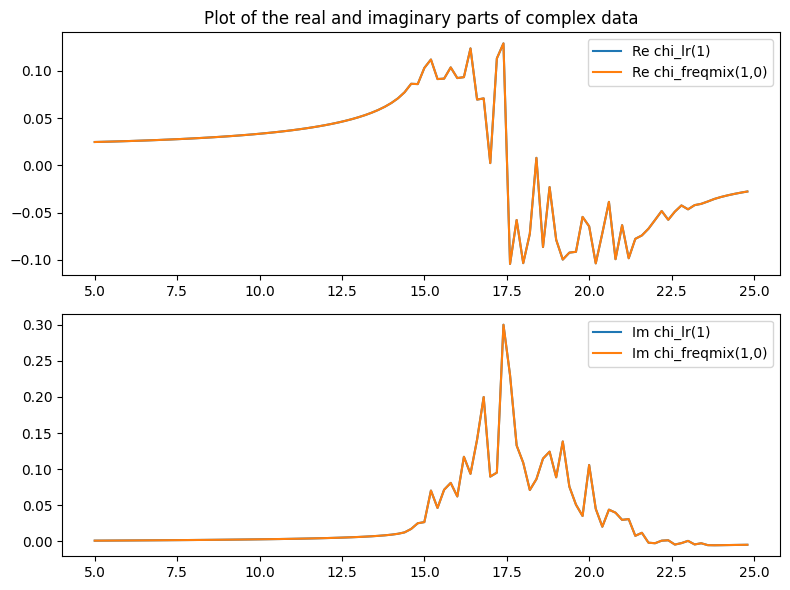

In [26]:
Utils.Plot_ComplexArray(freqs,chi_lr[0][1],label='chi_lr(1)',data2=chi_freqmix[0][(1,0)],label2='chi_freqmix(1,0)')

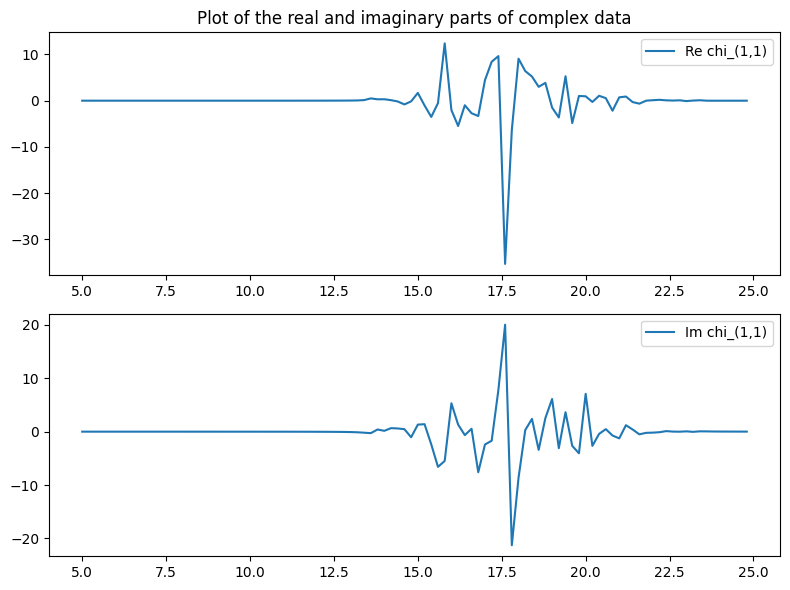

In [38]:
Utils.Plot_ComplexArray(freqs,chi_freqmix[0][(1,1)],label='chi_(1,1)')

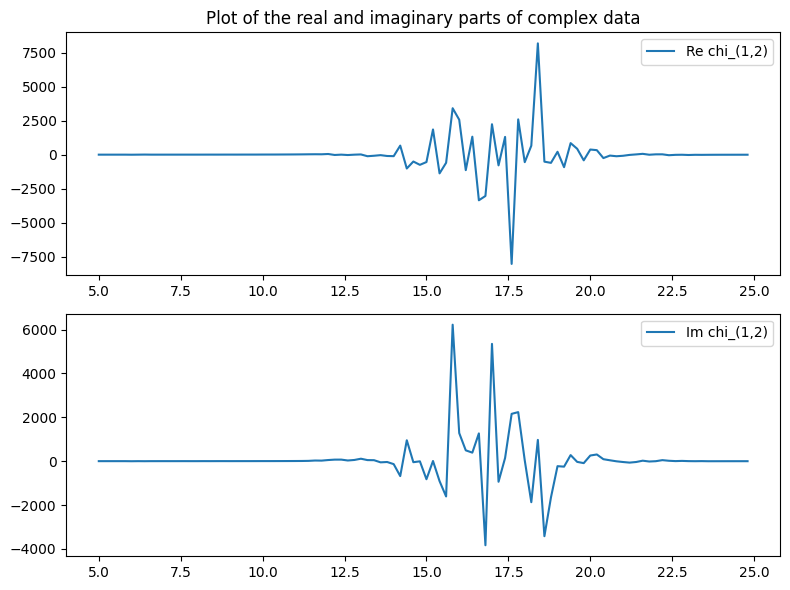

In [39]:
Utils.Plot_ComplexArray(freqs,chi_freqmix[0][(1,2)],label='chi_(1,2)')

In this way we are able to extract the non-linear chis for the relevant combinations of pump and probe fields.

There is one missing chi, namely the $(\omega_1,\omega_2,-\omega_2)$ which is at the same output frequency of the linear one.
For this signal to be detected is necessary to eliminate the linear part from the polarization.

A possilbe way is to consider the (relevant part of) the polarization as
$$
P(\omega,E_P) = E(\omega)\left(\chi^1(\omega)+\chi^3(\omega)E_P^2\right)
$$
so that
$$
S(\omega,E_P) = \frac{P(\omega,E_P)}{E(\omega)} = \chi^1(\omega)+\chi^3(\omega)E_P^2
$$
The difference of $S$ for the values of $E_P$ provides $\chi^3$
$$
S(\omega,E_1)-S(\omega,E_2) = \chi^3(\omega)(E_1^2-E_2^2))
$$
A possible choice could be to have $E_1$ finite (and big) with $E_2 = 0$. In this case the $\chi^3$ is computed as
$$
\chi^3(\omega) = \frac{S(\omega,E_1)-S(\omega,0)}{E_1^2}
$$


In [29]:
diffe = chi_freqmix[0][(1,0)] - chi_lr[0][1]
#diffe

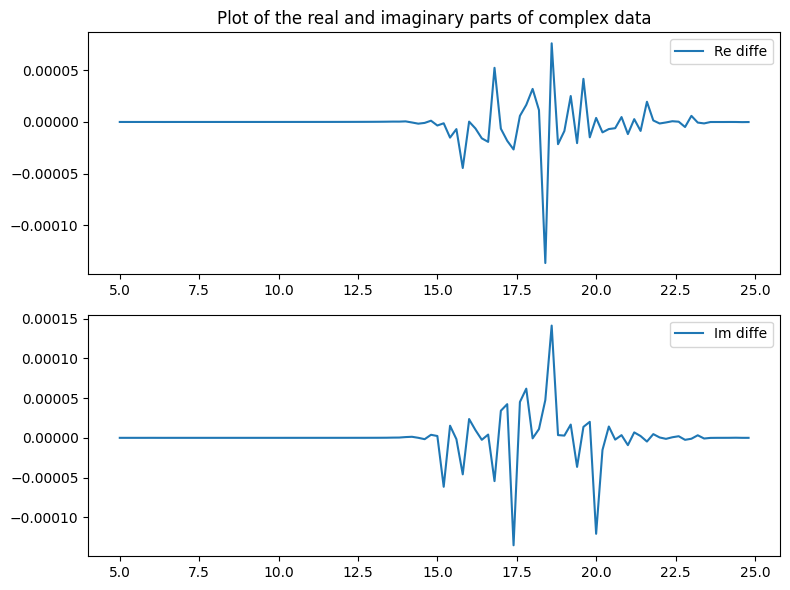

In [30]:
Utils.Plot_ComplexArray(freqs,diffe,label='diffe')

In [34]:
Ew = freq_mix.eval_Ew()
#Ew[(0,2)]

In [36]:
X3 = diffe/Ew[(0,2)]

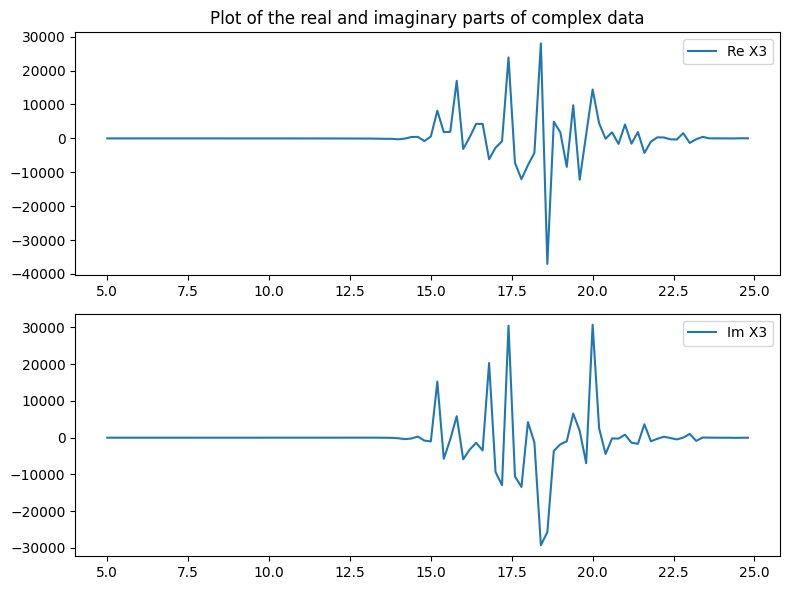

In [37]:
Utils.Plot_ComplexArray(freqs,X3,label='X3')

## Comparison of the NEQ vs NL-$\chi$ approaches

Now we compare the result for the transient absorption spectrum computed within the two approach.

To this scope we refer to the equation already discussed at the beginning of the notebook that (since we are interested in the variation w.r.t the equilibrium value)
can be written as

\begin{eqnarray}
\delta\chi^{neq,(1)}[E_P](\omega) &=& \chi^{neq,(1)}[E_P](\omega) - \chi^{(1)}(\omega;\omega) = \\
&& \left[ \chi^{(2)}(\omega;\omega_P,\omega-\omega_P)\frac{E_{p}(\omega-\omega_P)}{E_p(\omega)} + 
\chi^{(2)}(\omega;-\omega_P,\omega+\omega_P)\frac{E_{p}(\omega+\omega_P)}{E_p(\omega)}
\right]E_{P}(\omega_P)  + \nonumber \\ &+&\left[   
\chi^{(3)}(\omega;\omega_P,\omega_P,\omega-2\omega_P)\frac{E_{p}(\omega-2\omega_P)}{E_p(\omega)} + 
\chi^{(3)}(\omega;\omega_P,-\omega_P,\omega) + \right. \nonumber \\ &&\left.
\chi^{(3)}(\omega;-\omega_P,-\omega_P,\omega+2\omega_P)\frac{E_{p}(\omega+2\omega_P)}{E_p(\omega)}
\right]E^2_{P}(\omega_P)
\end{eqnarray}

In order to write an equation useful to compute the $\delta\chi^{neq}$ we analyze the previous formula addend by addend.

We parametrize the $\omega$ dependence in terms of the values of the probe, so that the two addends at the second order reads

$$
 \chi^{(2)}(\omega+\omega_P;\omega_P,\omega)\frac{E_{p}(\omega)}{E_p(\omega+\omega_P)} + 
\chi^{(2)}(\omega-\omega_P;-\omega_P,\omega)\frac{E_{p}(\omega)}{E_p(\omega-\omega_P)}
$$

Assuming tha the probe is a delta centred at $t_0$ in the time domain, its FT is given by $e^{i\omega t_0}$ so the ratios of probe fields simplify to

$$
\chi^{(2)}(\omega+\omega_P;\omega_P,\omega)e^{-i\omega_P \, t_0} + 
\chi^{(2)}(\omega-\omega_P;-\omega_P,\omega)e^{i\omega_P \, t_0}
$$

In the same way we can rewrite the third order addends as

$$
\chi^{(3)}(\omega;\omega_P,-\omega_P,\omega) +
\chi^{(3)}(\omega+2\omega_P;\omega_P,\omega_P,\omega)e^{-2i\omega_P \, t_0} + 
\chi^{(3)}(\omega-2\omega_P;-\omega_P,-\omega_P,\omega)e^{2i\omega_P \, t_0}
$$

In [3]:
#file_Pp = 'kx8_nb100_NoTr_E100/Pp-Ep_1e3-EP_1e6-PE_1.55-nlenrange_5.0-25.0-nlensteps_100-bands_3-6-damp_0.1-sin/ndb.Nonlinear'
#file_pulse = 'kx8_nb100_NoTr_E100/pulse-E1_1e3-nlenrange_5.0-25.0-nlensteps_100-bands_3-6-damp_0.1-sin/ndb.Nonlinear'
file_Pp = 'kx8_nb100_NoTr_E100/Pp-Ep_1e3-EP_1e6-PE_1.55-nlenrange_10.0-20.0-nlensteps_201-bands_3-6-damp_0.1-sin/ndb.Nonlinear'
file_pulse = 'kx8_nb100_NoTr_E100/pulse-E1_1e3-nlenrange_10.0-20.0-nlensteps_201-bands_3-6-damp_0.1-sin/ndb.Nonlinear'
data_Pp = P.YamboNLDBParser(file_Pp)
data_pulse = P.YamboNLDBParser(file_pulse)

freq_mix = O.Xn_frequency_mixing(data_Pp,X_order=(1,2),verbose=False)
single_freq = O.Xn_single_frequency(data_pulse,X_order=1,verbose=False)
chi_lr = single_freq.compute_Xn(set_units_of_measure=False)
chi_freqmix = freq_mix.compute_Xn(set_units_of_measure=False)

omega = freq_mix.probe_freqs*Const.HaToeV

Parse file : kx8_nb100_NoTr_E100/Pp-Ep_1e3-EP_1e6-PE_1.55-nlenrange_10.0-20.0-nlensteps_201-bands_3-6-damp_0.1-sin/ndb.Nonlinear
Field 3 not found
Parse file : kx8_nb100_NoTr_E100/pulse-E1_1e3-nlenrange_10.0-20.0-nlensteps_201-bands_3-6-damp_0.1-sin/ndb.Nonlinear
Field 2 not found
Field 3 not found


In [4]:
# compute the chi3(omega;omega_P,-omega_P,omega) by removing the linear part
diffe = chi_freqmix[0][(1,0)] - chi_lr[0][1]
Ew = freq_mix.eval_Ew()
X3 = diffe/Ew[(0,2)]

In [15]:
t0_fs = 10 # fs

omega_P = freq_mix.pump_freq
omega_P_eV = omega_P*Const.HaToeV
t0 = t0_fs*Const.FsToAu
phase = omega_P_eV*t0_fs/Const.Planck_reduced_ev_fs
phase

np.float64(23.548647690394112)

In [16]:
t0_fs = 10 # fs

omega_P = freq_mix.pump_freq
phase = omega_P*t0_fs*Const.FsToAu
phase

np.float64(23.548647714103353)

We build a single array with the second order addends. The array ranges in the domain from freqs[0]+omega_P_eV and omega[-1]-omega_P_eV where both the
addends have values

In [82]:
domega = omega[1]-omega[0]
ind_oP = round(omega_P_eV/domega)
omega_eff = omega[ind_oP:-ind_oP]

F2_1 = chi_freqmix[0][(1,1)]*np.exp(-1j*phase)
F2_2 = chi_freqmix[0][(1,-1)]*np.exp(1j*phase)
F2_sum = F2_1[2*ind_oP:] + F2_2[:-2*ind_oP]

In [83]:
len(omega_eff),len(F2_sum),omega_eff[0],omega_eff[-1]

(139, 139, np.float64(11.542289660059376), np.float64(18.407961957853317))

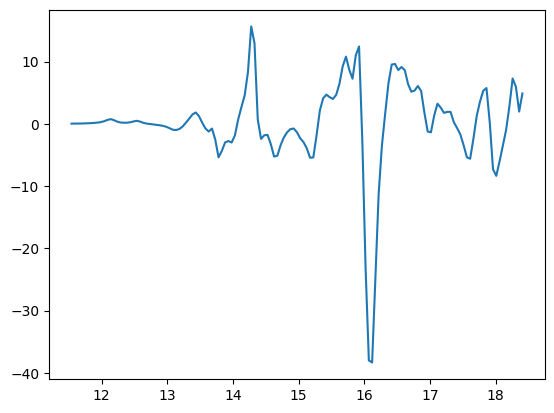

In [84]:
plt.plot(omega_eff,np.imag(F2_sum))

We do the same procedure for the third order addends

In [96]:
domega = omega[1]-omega[0]
ind_oP = round(omega_P_eV/domega)
omega_eff = omega[2*ind_oP:-2*ind_oP]

F3_1 = chi_freqmix[0][(1,2)]*np.exp(-1j*2*phase)
F3_2 = X3
F3_3 = chi_freqmix[0][(1,-2)]*np.exp(1j*2*phase)

F3_sum = F3_1[4*ind_oP:] + F3_2[2*ind_oP:-2*ind_oP] + F3_3[:-4*ind_oP]

In [97]:
len(omega_eff),len(F3_sum),omega_eff[0],omega_eff[-1]

(77, 77, np.float64(13.084578364636275), np.float64(16.865673253276416))

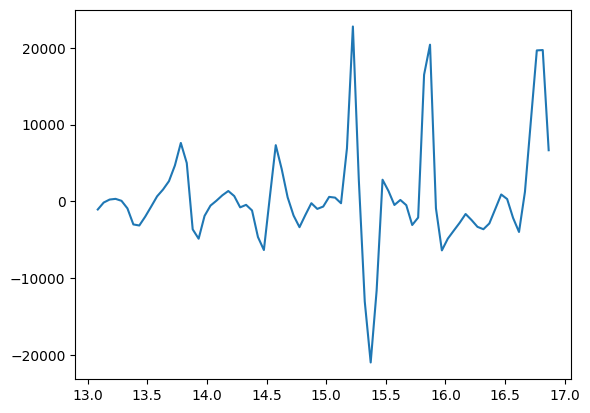

In [98]:
plt.plot(omega_eff,np.imag(F3_sum))

We build a single procedure for the construction of both the second and third order addends in the common omega range

In [108]:
domega = omega[1]-omega[0]
ind_oP = round(omega_P_eV/domega)
omega_eff = omega[2*ind_oP:-2*ind_oP]

F2_1 = chi_freqmix[0][(1,1)]*np.exp(-1j*phase)
F2_2 = chi_freqmix[0][(1,-1)]*np.exp(1j*phase)
F2_sum_long = F2_1[2*ind_oP:] + F2_2[:-2*ind_oP]
F2_sum = F2_sum_long[ind_oP:-ind_oP]

F3_1 = chi_freqmix[0][(1,2)]*np.exp(-1j*2*phase)
F3_2 = X3
F3_3 = chi_freqmix[0][(1,-2)]*np.exp(1j*2*phase)
F3_sum = F3_1[4*ind_oP:] + F3_2[2*ind_oP:-2*ind_oP] + F3_3[:-4*ind_oP]

In [109]:
len(omega_eff),len(F2_sum),len(F3_sum)

(77, 77, 77)

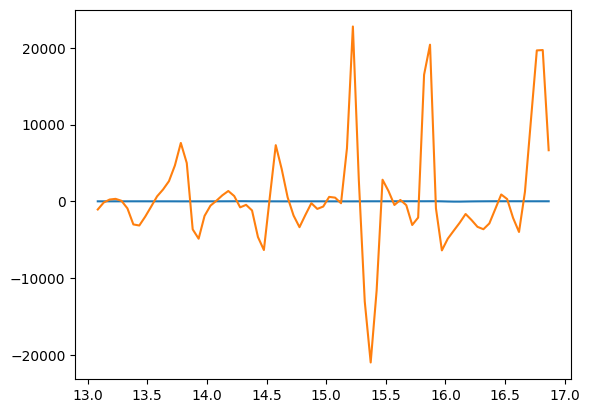

In [111]:
plt.plot(omega_eff,np.imag(F2_sum))
plt.plot(omega_eff,np.imag(F3_sum))

In [118]:
EP = data_Pp.Efield2[0]['amplitude']
EP

np.float64(0.00011936186233841526)

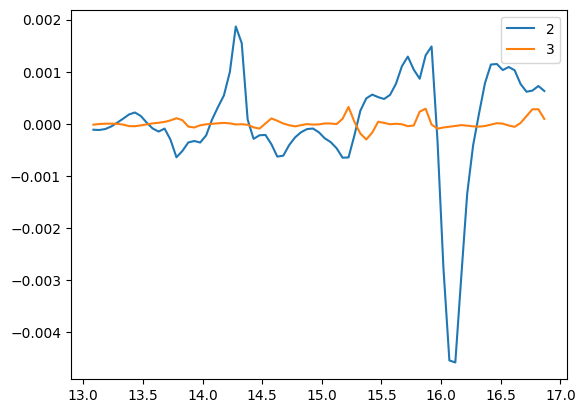

In [120]:
plt.plot(omega_eff,np.imag(F2_sum)*EP,label='2')
plt.plot(omega_eff,np.imag(F3_sum)*EP**2,label='3')
plt.legend()

Now we build a function that computes the dchi_neq and compare the resutls with the one of the first approach

In [42]:
def eval_dchi_neq(omega,omega_P,tau,EP,x11,x1m1,x11m1,x12,x1m2):
    """
    We compute the variation of the neq absorption

    Args:
        omega : energy range of the probe (Hartree)
        omega_P : energy of the pump (Hartree)
        tau : time delay of the probe w.r.t. the pump (fs)
        EP : amplitude of the pump
        x11 : chi(omega+omega_P;omega_P,omega)
        x1m1 : chi(omega-omega_P;-omega_P,omega)
        x10 : chi(omega,omega_P,-omega_P,omega) extracted as the non-linear part
            of chi(omega)
        x12 : chi(omega+2*omega_P;omega_P,omega_P,omega)
        x1m2 : chi(omega-2*omega_P;-omega_P,-omega_P,omega)
    """
    domega = omega[1]-omega[0]
    ind_oP = round(omega_P/domega)
    omega_eff = omega[2*ind_oP:-2*ind_oP]
    phase = omega_P*tau*Const.FsToAu # corresponds to omega*t/hbar

    F2_1 = x11*np.exp(-1j*phase)
    F2_2 = x1m1*np.exp(1j*phase)
    F2_sum = F2_1[2*ind_oP:] + F2_2[:-2*ind_oP]
    F2_sum_cut = F2_sum[ind_oP:-ind_oP] # cut the part the is not present in the cubic terms

    F3_1 = x12*np.exp(-1j*2*phase)
    F3_2 = x11m1
    F3_3 = x1m2*np.exp(1j*2*phase)
    F3_sum = F3_1[4*ind_oP:] + F3_2[2*ind_oP:-2*ind_oP] + F3_3[:-4*ind_oP]

    dchi_neq = F2_sum_cut*EP+F3_sum*EP**2

    return omega_eff,dchi_neq

import re

def build_delta_dict(path='.'):
    """
    Scan all folders inside `path` and build a dictionary
    using the value contained in 'deltaXX.XXfs' as key.

    Returns
    -------
    dict
        Dictionary of the form

            {
                delta_value: folder_name
            }

    Notes
    -----
    If multiple folders have the same delta value,
    the last one found will overwrite the previous one.
    """

    delta_dict = {}

    # Regular expression used to extract the delta value
    # Example match: delta10.00fs -> 10.00
    pattern = re.compile(r'delta([0-9]+\.?[0-9]*)fs')

    # Loop over all entries in the directory
    for folder in os.listdir(path):

        full_path = os.path.join(path, folder)

        # Process only directories
        if os.path.isdir(full_path):

            # Search for the delta pattern in the folder name
            match = pattern.search(folder)

            if match:

                # Convert extracted value to float
                delta = float(match.group(1))

                # Store folder name in the dictionary
                delta_dict[delta] = folder

    return delta_dict

    

In [33]:
file_Pp = 'kx8_nb100_NoTr_E100/Pp-Ep_1e3-EP_1e6-PE_1.55-nlenrange_10.0-20.0-nlensteps_201-bands_3-6-damp_0.1-sin/ndb.Nonlinear'
file_pulse = 'kx8_nb100_NoTr_E100/pulse-E1_1e3-nlenrange_10.0-20.0-nlensteps_201-bands_3-6-damp_0.1-sin/ndb.Nonlinear'
data_Pp = P.YamboNLDBParser(file_Pp)
data_pulse = P.YamboNLDBParser(file_pulse)

freq_mix = O.Xn_frequency_mixing(data_Pp,X_order=(1,2),verbose=False)
single_freq = O.Xn_single_frequency(data_pulse,X_order=1,verbose=False)
chi_lr = single_freq.compute_Xn(set_units_of_measure=False)
chi_freqmix = freq_mix.compute_Xn(set_units_of_measure=False)

omega = freq_mix.probe_freqs
EP = data_Pp.Efield2[0]['amplitude']
omega_P = freq_mix.pump_freq

Parse file : kx8_nb100_NoTr_E100/Pp-Ep_1e3-EP_1e6-PE_1.55-nlenrange_10.0-20.0-nlensteps_201-bands_3-6-damp_0.1-sin/ndb.Nonlinear
Field 3 not found
Parse file : kx8_nb100_NoTr_E100/pulse-E1_1e3-nlenrange_10.0-20.0-nlensteps_201-bands_3-6-damp_0.1-sin/ndb.Nonlinear
Field 2 not found
Field 3 not found


In [43]:
# compute the second and third order chis
x11 = chi_freqmix[0][(1,1)]
x1m1 = chi_freqmix[0][(1,-1)]
x12 = chi_freqmix[0][(1,2)]
x1m2 = chi_freqmix[0][(1,-2)]

# compute the chi3(omega;omega_P,-omega_P,omega) by removing the linear part
diffe = chi_freqmix[0][(1,0)] - chi_lr[0][1]
Ew = freq_mix.eval_Ew()
x11m1 = diffe/Ew[(0,2)]

In [44]:
path = 'Davide_data/20250312_Report_simulations_data_kx16_ball/'
deltas_folder = build_delta_dict(path=path)
deltas = list(deltas_folder.keys())

Parse file Davide_data/20250312_Report_simulations_data_kx16_ball/td-ip-ber_3.0as_inv_1-15b_qsf90pi1.56_6.0E9_deph0.0eV_delta10.00fs_Pp_NL/o-abs_0-50eV_sm0.6eV.YPP-eps_along_E


(10.0, 20.0)

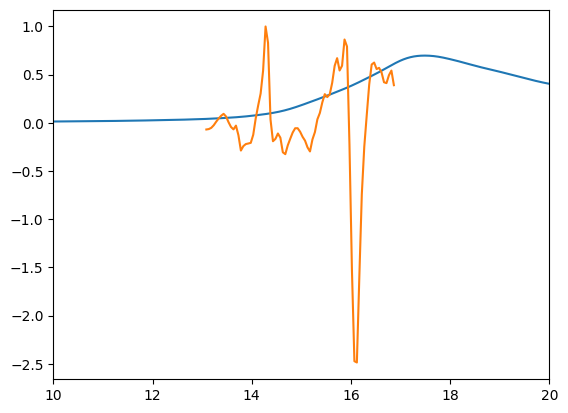

In [54]:
tau = deltas[0]

data = P.YamboOutputParser.from_file(os.path.join(path,deltas_folder[tau],'o-abs_0-50eV_sm0.6eV.YPP-eps_along_E'))['YPP-eps_along_E']
energy = data['col1']
eps_im = data['col2']
omega_eff, dchi_neq = eval_dchi_neq(omega,omega_P,tau,EP,x11,x1m1,x11m1,x12,x1m2)

abs_chi = np.imag(dchi_neq)/max(np.imag(dchi_neq))

plt.plot(energy,eps_im/max(eps_im))
plt.plot(omega_eff*Const.HaToeV,abs_chi)
plt.xlim(10,20)

In [18]:
path = 'Davide_data/20250312_Report_simulations_data_kx16_ball/'
deltas_folder = build_delta_dict(path=path)
deltas_folder.keys()

dict_keys([10.0, 10.25, 10.5, 10.75, 11.0, 11.25, 11.5, 11.75, 12.0, 12.25, 12.5, 12.75, 13.0, 13.25, 13.5, 13.75, 14.0, 14.25, 14.5, 14.75, 15.0, 15.25, 15.5, 15.75, 16.0, 16.25, 16.5, 16.75, 17.0, 17.25, 17.5, 17.75, 18.0, 18.25, 18.5, 18.75, 19.0, 19.25, 19.5, 19.75, 20.0, 20.25, 20.5, 20.75, 21.0, 21.25, 21.5, 21.75, 22.0, 22.25, 22.5, 22.75, 23.0, 23.25, 5.25, 8.5, 8.75, 9.0, 9.25, 9.5, 9.75, 23.5, 23.75, 24.0])

Parse file Davide_data/20250312_Report_simulations_data_kx16_ball/td-ip-ber_3.0as_inv_1-15b_qsf90pi1.56_6.0E9_deph0.0eV_delta9.50fs_Pp_NL/o-abs_0-50eV_sm0.6eV.YPP-eps_along_E


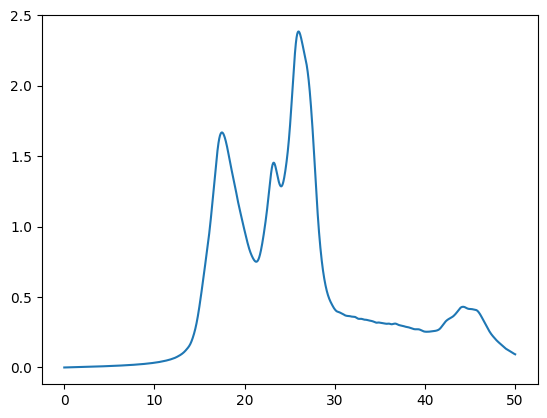

In [22]:
delta = 9.5
data = P.YamboOutputParser.from_file(os.path.join(path,deltas_folder[delta],'o-abs_0-50eV_sm0.6eV.YPP-eps_along_E'))['YPP-eps_along_E']
energy = data['col1']
eps_im = data['col2']
plt.plot(energy,eps_im)